In [171]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import pmdarima as pm

In [172]:
df=pd.read_csv('cleaned_online_retail.csv')

In [173]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [174]:
df['InvoiceDate'] = df['InvoiceDate'].dt.date

In [175]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [176]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom,20.34


<Axes: >

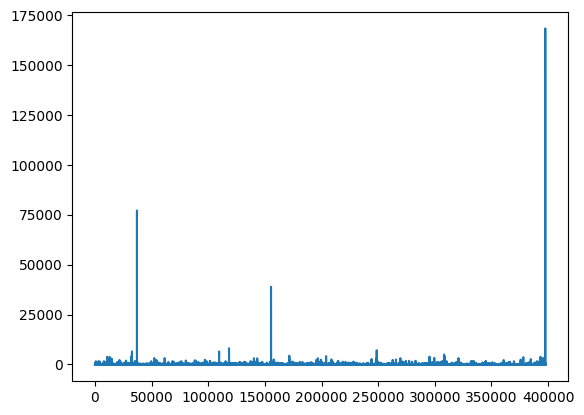

In [177]:
df['TotalPrice'].plot()

In [178]:
df['TotalPrice'].describe()

count    397924.000000
mean         22.394749
std         309.055588
min           0.000000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64

<Axes: >

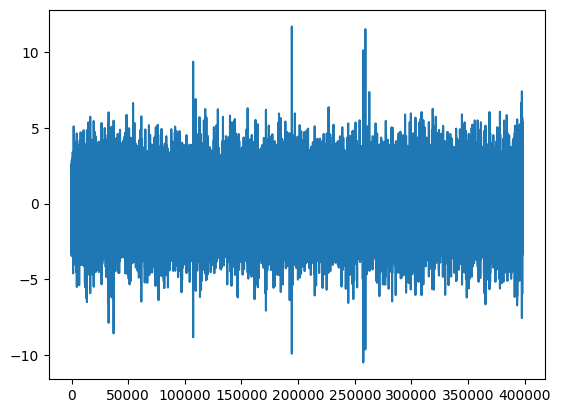

In [179]:
data.plot()

(0.0, 5000.0)

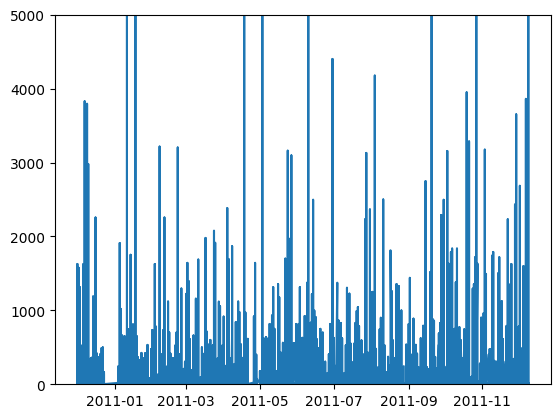

In [180]:
plt.plot(df['InvoiceDate'],df['TotalPrice'])
plt.ylim(0, 5000)

### Univariate Analysis

In [181]:
daily_sales = df.groupby('InvoiceDate')['TotalPrice'].sum()
print(daily_sales.head())

InvoiceDate
2010-12-01    46376.49
2010-12-02    47316.53
2010-12-03    23921.71
2010-12-05    31771.60
2010-12-06    31215.64
Name: TotalPrice, dtype: float64


In [182]:
daily_sales.describe()

count       305.000000
mean      29217.730833
std       17854.997860
min        3457.110000
25%       18021.481000
50%       25489.660000
75%       36751.250000
max      184349.280000
Name: TotalPrice, dtype: float64

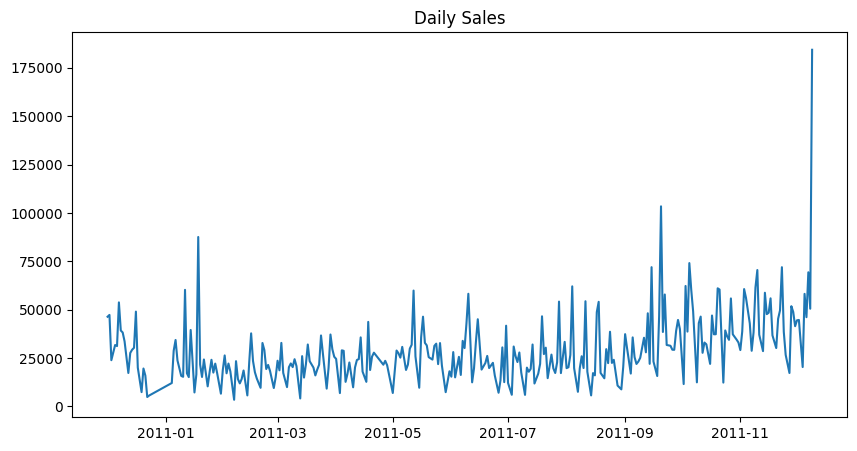

In [183]:
plt.figure(figsize=(10,5))
plt.plot(daily_sales)
plt.title("Daily Sales")
plt.show()

In [184]:
daily_sales.shape

(305,)

In [185]:
result = adfuller(daily_sales)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -0.366093
p-value: 0.915608


In [186]:
result_sales = kpss(daily_sales)
print("KPSS Statistic:", result_sales[0])
print("p-value:", result_sales[1])

KPSS Statistic: 1.899550618616463
p-value: 0.01


C:\Users\Pratham\AppData\Local\Temp\ipykernel_14224\3397716390.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_sales = kpss(daily_sales)


<Axes: xlabel='TotalPrice'>

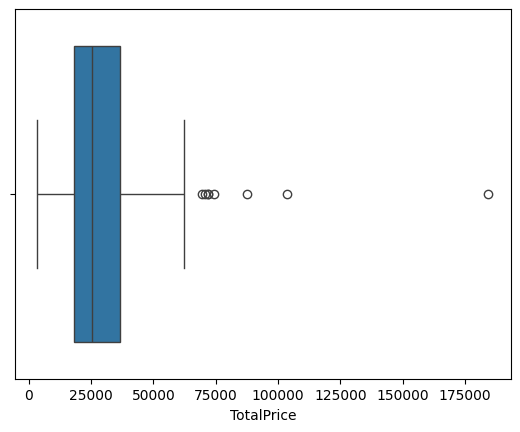

In [187]:
sns.boxplot(x=daily_sales)

In [188]:
model = pm.auto_arima(
    daily_sales,
    seasonal=True,
    m=30,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[30] intercept   : AIC=inf, Time=2.58 sec
 ARIMA(0,1,0)(0,0,0)[30] intercept   : AIC=6871.353, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[30] intercept   : AIC=6821.563, Time=0.17 sec
 ARIMA(0,1,1)(0,0,1)[30] intercept   : AIC=6754.819, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[30]             : AIC=6869.520, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[30] intercept   : AIC=6745.968, Time=0.11 sec
 ARIMA(0,1,1)(1,0,0)[30] intercept   : AIC=6743.627, Time=0.59 sec
 ARIMA(0,1,1)(2,0,0)[30] intercept   : AIC=6742.069, Time=3.02 sec
 ARIMA(0,1,1)(2,0,1)[30] intercept   : AIC=inf, Time=5.63 sec
 ARIMA(0,1,1)(1,0,1)[30] intercept   : AIC=inf, Time=1.71 sec
 ARIMA(0,1,0)(2,0,0)[30] intercept   : AIC=6869.559, Time=0.63 sec
 ARIMA(1,1,1)(2,0,0)[30] intercept   : AIC=6756.165, Time=1.15 sec
 ARIMA(0,1,2)(2,0,0)[30] intercept   : AIC=6739.800, Time=4.74 sec
 ARIMA(0,1,2)(1,0,0)[30] intercept   : AIC=6741.690, Time=0.96 sec
 ARIMA(0,1,2)(2,0,1)[30] intercept

In [ ]:
daily_diff=daily_sales.diff().dropna()
weekly_diff=daily_sales.diff(7).dropna()

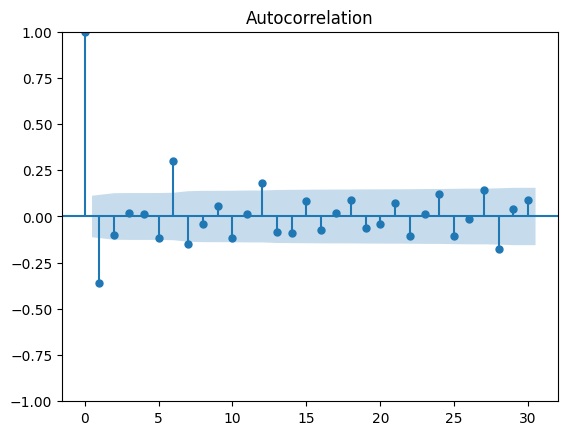

In [ ]:
plot_acf(daily_diff,lags=30)
plt.show()

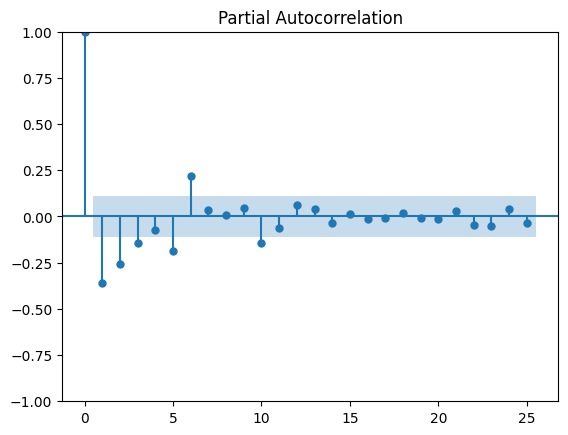

In [196]:
plot_pacf(daily_diff)
plt.show()

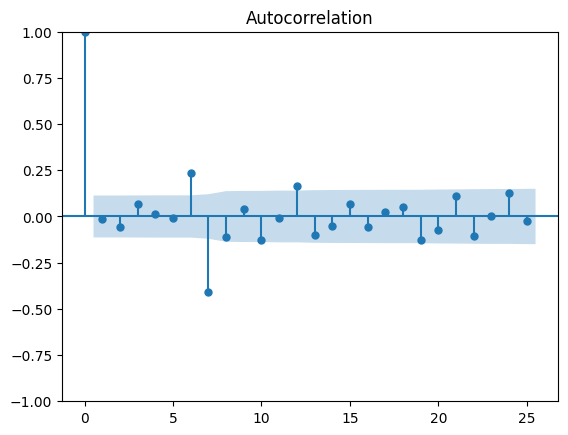

In [200]:
plot_acf(weekly_diff)
plt.show()

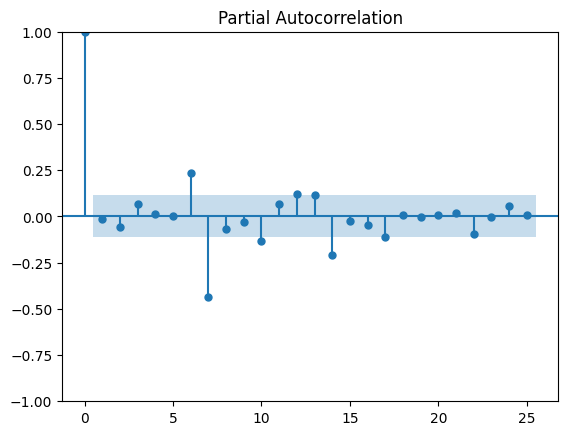

In [201]:
plot_pacf(weekly_diff)
plt.show()

In [271]:
model=SARIMAX(
    daily_sales,
    order=(1,1,2),
    seasonal_order=(1,1,2,30)
)
model=model.fit()
print(model.summary())


C:\Users\Pratham\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Pratham\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         TotalPrice   No. Observations:                  305
Model:             SARIMAX(1, 1, 2)x(1, 1, 2, 30)   Log Likelihood               -3052.694
Date:                            Wed, 08 Apr 2026   AIC                           6119.387
Time:                                    09:17:56   BIC                           6144.679
Sample:                                         0   HQIC                          6129.539
                                            - 305                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9514      0.129     -7.401      0.000      -1.203      -0.699
ma.L1          0.0447      0.152   

C:\Users\Pratham\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Pratham\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


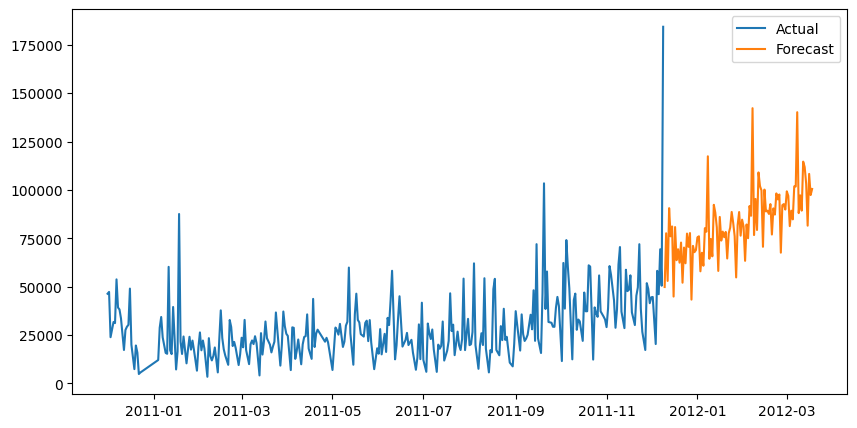

In [272]:
forecast = model.forecast(steps=100)
forecast_index = pd.date_range( start=daily_sales.index[-1] + pd.Timedelta(days=1), periods=100, freq='D' ) 
plt.figure(figsize=(10,5)) 
plt.plot(daily_sales, label='Actual') 
plt.plot(forecast_index, forecast, label='Forecast') 
plt.legend() 
plt.show()